# Discussion Activity 7
- Author: Robert Feconda

Data Geometry (Lecture 7A)
You are given a dataset of 10 points in 2D space:
~~~
x	y
2.5	2.4
0.5	0.7
2.2	2.9
1.9	2.2
3.1	3.0
2.3	2.7
2.0	1.6
1.0	1.1
1.5	1.6
1.1	0.9
~~~
Treat each row is a vector in $R^2$.

Your goal is to describe the shape of this dataset by computing and interpreting the eigenvalues and eigenvectors of its covariance matrix.

(a) Center the Data by subtracting the mean of each column (x and y) from every point.

(b) Calculate the 2 × 2 covariance matrix using the centered data.

(c) Compute the eigenvalues and eigenvectors of the covariance matrix.

(d) Visualize the geometry:

Create a scatter plot of the centered dataset.
Draw the eigenvectors as arrows from the origin, scaled by the square root of their eigenvalues.
You may use Python/matplotlib, but interpretation is required.

Answer briefly:

(e) What does each eigenvector represent geometrically?

(f) How do the eigenvalues relate to “spread” (variance) in each direction?

(g) If you compress the data to 1D, which eigenvector would you project onto and why?

## Response 1

Column means [x_mean, y_mean]:
[1.81 1.91]

Centered data:
[[ 0.69  0.49]
 [-1.31 -1.21]
 [ 0.39  0.99]
 [ 0.09  0.29]
 [ 1.29  1.09]
 [ 0.49  0.79]
 [ 0.19 -0.31]
 [-0.81 -0.81]
 [-0.31 -0.31]
 [-0.71 -1.01]]

Covariance matrix:
[[0.616556 0.615444]
 [0.615444 0.716556]]

Eigenvalues (largest to smallest):
[1.284028 0.049083]

Eigenvectors (columns correspond to eigenvalues):
[[-0.677873 -0.735179]
 [-0.735179  0.677873]]


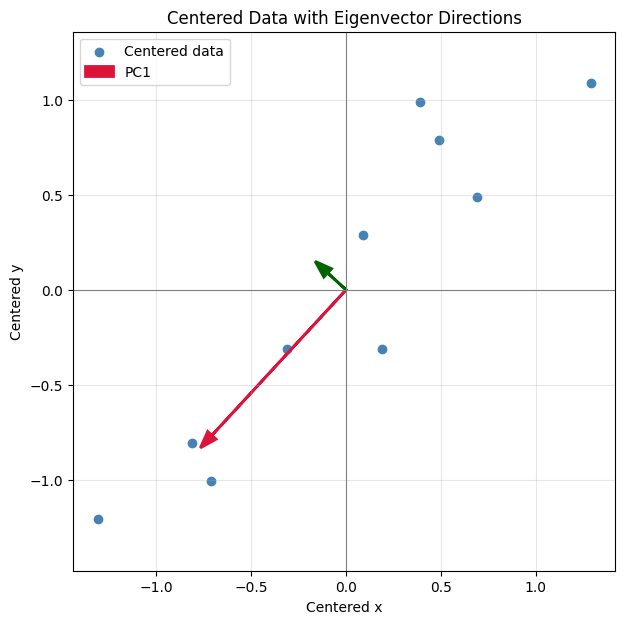

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Original 2D dataset (x, y)
data_points = np.array([
    [2.5, 2.4],
    [0.5, 0.7],
    [2.2, 2.9],
    [1.9, 2.2],
    [3.1, 3.0],
    [2.3, 2.7],
    [2.0, 1.6],
    [1.0, 1.1],
    [1.5, 1.6],
    [1.1, 0.9]
], dtype=float)

#Center the data by subtracting column means
column_means = np.mean(data_points, axis=0)
centered_data_points = data_points - column_means

#Covariance matrix of centered data
covariance_matrix = np.cov(centered_data_points, rowvar=False)

#Eigenvalues and eigenvectors
raw_eigenvalues, raw_eigenvectors = np.linalg.eig(covariance_matrix)

# Sort from largest eigenvalue to smallest for easier interpretation
sorted_indices = np.argsort(raw_eigenvalues)[::-1]
eigenvalues = raw_eigenvalues[sorted_indices]
eigenvectors = raw_eigenvectors[:, sorted_indices]

# Print numeric results
print("Column means [x_mean, y_mean]:")
print(column_means)
print("\nCentered data:")
print(np.round(centered_data_points, 2))
print("\nCovariance matrix:")
print(np.round(covariance_matrix, 6))
print("\nEigenvalues (largest to smallest):")
print(np.round(eigenvalues, 6))
print("\nEigenvectors (columns correspond to eigenvalues):")
print(np.round(eigenvectors, 6))

#Plot centered data and eigenvector directions
plt.figure(figsize=(7, 7))
plt.scatter(centered_data_points[:, 0], centered_data_points[:, 1], color="steelblue", label="Centered data")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)

# Scale each eigenvector by sqrt(eigenvalue) so arrow length shows spread
for i in range(len(eigenvalues)):
    scaled_vector = eigenvectors[:, i] * np.sqrt(eigenvalues[i])
    plt.arrow(
        0, 0,
        scaled_vector[0], scaled_vector[1],
        head_width=0.06,
        length_includes_head=True,
        linewidth=2,
        color="crimson" if i == 0 else "darkgreen",
        label=f"PC{i+1}" if i == 0 else None
    )

plt.title("Centered Data with Eigenvector Directions")
plt.xlabel("Centered x")
plt.ylabel("Centered y")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

After centering the data, the mean of the original points is approximately **(1.81, 1.91)**, so each point is shifted by subtracting those values from $x$ and $y$.

The covariance matrix is approximately:

$$
\begin{bmatrix}
0.6166 & 0.6154 \\
0.6154 & 0.7166
\end{bmatrix}
$$

The eigenvalues are approximately:

- $\lambda_1 \approx 1.2840$
- $\lambda_2 \approx 0.0491$

The first eigenvalue is much larger, which tells us the data is stretched mostly in one main direction.

- **Geometric meaning of each eigenvector:**  
  Each eigenvector is a direction in the 2D plane.  
  The eigenvector for the largest eigenvalue points along the longest direction of the data cloud (the principal trend).  
  The eigenvector for the smaller eigenvalue points in the perpendicular direction, where the data has much less variation.  
  Visually, they act like the major and minor axes of the centered data distribution.

- **How eigenvalues relate to spread (variance):**  
  Eigenvalues tell us how much variance exists along their matching eigenvectors.  
  Larger eigenvalue means more spread in that direction, and smaller eigenvalue means less spread.  
  In this case, about **96.3%** of the variance is along the first eigenvector and about **3.7%** is along the second, so the dataset is close to one-dimensional.

- **If compressing the data to 1D:**  
  Project onto the eigenvector associated with the largest eigenvalue (the first principal component).  
  This keeps the most information from the original 2D data and gives the best 1D summary.
```

## SVD and Compression (Lecture 7B)

- Use the same centered dataset from Activity #1.

- Let $X \in \mathbb{R}^{10 \times 2}$ be the centered data matrix, where each row is one centered point.

- (a) Compute the SVD:
$$
X = U \Sigma V^T
$$

- Answer:
  - What are the singular values $\sigma_1, \sigma_2$?
  - What are the right singular vectors (the columns of $V$)?
  - How do the right singular vectors compare to the eigenvectors you computed in Activity #1?

- You may compute SVD using a numerical tool such as NumPy. No hand-derivation is expected.

- (b) Construct the rank-1 approximation:
$$
X_1 = \sigma_1 u_1 v_1^T
$$

- This keeps only the largest singular value (the strongest direction).

- Then:
  - Plot the original centered data.
  - Plot the reconstructed rank-1 points (rows of $X_1$).
  - Draw the dominant direction $v_1$.

- (c) Compute
$$
\sigma_1^2, \sigma_2^2
$$

- Then answer:
  - What fraction of the total variation is captured by keeping only $\sigma_1$?
  - What does the smaller singular value represent geometrically?

- Answer briefly:

- (d) Why does keeping only the largest singular value “compress” the dataset?

- (e) What kind of structure is preserved in a rank-1 approximation?

- (f) If this dataset contained noise, how might low-rank approximation help?

## Response 2

Singular values [sigma1, sigma2]:
[3.399448 0.664643]

Right singular vectors (columns of V):
[[-0.677873  0.735179]
 [-0.735179 -0.677873]]

sigma1^2 and sigma2^2:
[11.556249  0.441751]

Fraction captured by sigma1:
0.963181


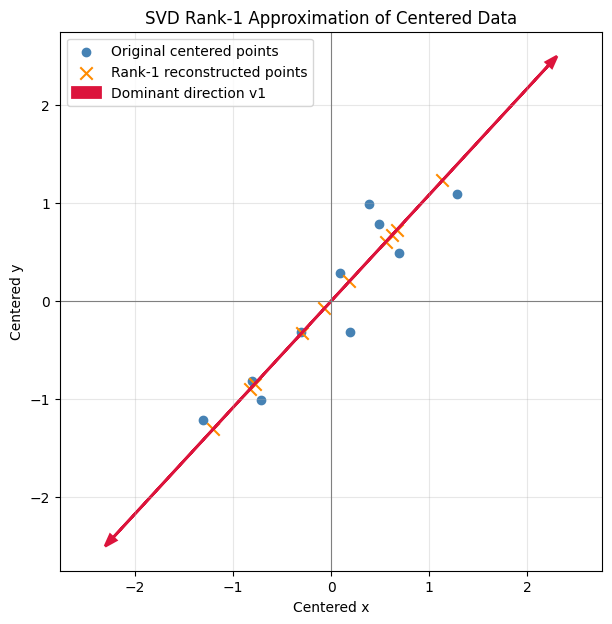

In [2]:
# This is X in R^(10x2)
centered_data_matrix = centered_data_points

# Compute SVD
left_singular_vectors, singular_values, right_singular_vectors_transposed = np.linalg.svd(
    centered_data_matrix,
    full_matrices=False
)

# Right singular vectors are columns of V
right_singular_vectors = right_singular_vectors_transposed.T

# Rank-1 approximation
largest_singular_value = singular_values[0]
first_left_singular_vector = left_singular_vectors[:, 0]
first_right_singular_vector = right_singular_vectors[:, 0]

rank_one_approximation = largest_singular_value * np.outer(
    first_left_singular_vector,
    first_right_singular_vector
)

# Compute captured variation
singular_value_1_squared = singular_values[0] ** 2
singular_value_2_squared = singular_values[1] ** 2
fraction_of_variation_captured = singular_value_1_squared / (
    singular_value_1_squared + singular_value_2_squared
)

print("Singular values [sigma1, sigma2]:")
print(np.round(singular_values, 6))

print("\nRight singular vectors (columns of V):")
print(np.round(right_singular_vectors, 6))

print("\nsigma1^2 and sigma2^2:")
print(np.round([singular_value_1_squared, singular_value_2_squared], 6))

print("\nFraction captured by sigma1:")
print(np.round(fraction_of_variation_captured, 6))

# Plot original centered points and rank-1 reconstructed points
plt.figure(figsize=(7, 7))
plt.scatter(
    centered_data_matrix[:, 0], centered_data_matrix[:, 1],
    color="steelblue", label="Original centered points"
)
plt.scatter(
    rank_one_approximation[:, 0], rank_one_approximation[:, 1],
    color="darkorange", marker="x", s=80, label="Rank-1 reconstructed points"
)

# Draw dominant direction v1 from origin
dominant_direction_for_plot = first_right_singular_vector * largest_singular_value
plt.arrow(
    0, 0,
    dominant_direction_for_plot[0], dominant_direction_for_plot[1],
    head_width=0.08, length_includes_head=True,
    color="crimson", linewidth=2
)
plt.arrow(
    0, 0,
    -dominant_direction_for_plot[0], -dominant_direction_for_plot[1],
    head_width=0.08, length_includes_head=True,
    color="crimson", linewidth=2, label="Dominant direction v1"
)

plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("SVD Rank-1 Approximation of Centered Data")
plt.xlabel("Centered x")
plt.ylabel("Centered y")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


Using the centered data matrix $X \in \mathbb{R}^{10 \times 2}$, I computed the SVD:

$$
X = U \Sigma V^T
$$

- **Singular values:**
  - $\sigma_1 \approx 3.3994$
  - $\sigma_2 \approx 0.6646$

- **Right singular vectors (columns of $V$):**
  - First direction is approximately $[0.6779,\ 0.7352]^T$
  - Second direction is approximately $[0.7352,\ -0.6779]^T$
  - Depending on software output, signs can flip (for example, $[-0.6779, -0.7352]^T$ is the same direction)

- **Comparison to Activity 1 eigenvectors:**
  - They match the covariance eigenvectors up to a sign.
  - So the main geometric directions from PCA and from SVD are the same here.

- **Rank-1 approximation:**
  - I built $X_1 = \sigma_1 u_1 v_1^T$, which keeps only the strongest direction.
  - In the plot, the reconstructed points sit along one dominant line, while the original centered points are a little spread around it.

- **Squared singular values:**
  - $\sigma_1^2 \approx 11.5562$
  - $\sigma_2^2 \approx 0.4418$

- **Fraction of total variation captured by $\sigma_1$:**
  $$
  \frac{\sigma_1^2}{\sigma_1^2 + \sigma_2^2} \approx 0.9632
  $$
  So about **96.3%** of the variation is captured with rank 1.

- **Geometric meaning of the smaller singular value:**
  - $\sigma_2$ measures the leftover spread perpendicular to the main direction.
  - In this dataset, it is small, so the cloud is close to a line.

- **Why keeping only the largest singular value compresses the dataset:**
  - We replace each 2D point with a single coordinate along the dominant direction, then reconstruct from that.
  - That means fewer numbers are needed while still preserving most of the structure.

- **What structure is preserved in rank-1 approximation:**
  - The global trend and dominant orientation of the data.
  - Relative ordering of points along that main axis is mostly preserved.

- **How low-rank approximation helps with noise:**
  - Noise often appears in weaker directions (small singular values).
  - Dropping those weaker components can smooth out random variation and keep the meaningful pattern.
